# 🔍 Transaction Fraud Detection - Rule-Based Algorithms

This notebook implements **6 rule-based detection algorithms** for identifying fraudulent transactions:

1. **Amount Anomaly** (Statistical Z-Score)
2. **Location Deviation**
3. **Temporal Analysis**
4. **Velocity Check**
5. **Category Deviation**
6. **Geographic Impossibility** (Strongest Signal)

## Step 1: Install & Import Dependencies

In [27]:
!pip install pandas numpy scikit-learn matplotlib seaborn kagglehub --quiet

In [28]:
import pandas as pd
import numpy as np
from math import radians, cos, sin, asin, sqrt
from datetime import datetime, timedelta
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('All imports successful!')

All imports successful!


## Step 2: Load Dataset

**Option A** - Download from Kaggle using `kagglehub` (recommended - Sparkov fraud dataset with location, category, timestamps).

**Option B** - Use a built-in synthetic data generator if you prefer to work offline.

**Option C** - Upload your own CSV file.

In [29]:
# =============== CHOOSE YOUR DATA SOURCE ===============
DATA_SOURCE = 'kaggle'  # Options: 'kaggle', 'synthetic', 'custom'
CUSTOM_CSV_PATH = ''     # Only used if DATA_SOURCE = 'custom'
# =======================================================

In [30]:
def generate_synthetic_data(n_users=50, n_transactions=5000):
    """Generate synthetic transaction data with realistic patterns."""
    np.random.seed(42)
    cities = {
        'New York': (40.71, -74.01), 'Boston': (42.36, -71.06),
        'Chicago': (41.88, -87.63), 'Los Angeles': (34.05, -118.24),
        'Miami': (25.76, -80.19), 'Tokyo': (35.68, 139.69),
        'London': (51.51, -0.13), 'Paris': (48.86, 2.35)
    }
    categories = ['grocery', 'gas_transport', 'food_dining', 'shopping_net',
                  'entertainment', 'health_fitness', 'electronics', 'travel']
    us_cities = ['New York', 'Boston', 'Chicago', 'Los Angeles', 'Miami']

    user_profiles = {}
    for uid in range(n_users):
        home = np.random.choice(us_cities)
        user_profiles[uid] = {
            'home_city': home, 'home_lat': cities[home][0], 'home_lon': cities[home][1],
            'avg_amount': np.random.uniform(20, 200),
            'std_amount': np.random.uniform(10, 50),
            'usual_categories': list(np.random.choice(categories[:5], size=3, replace=False)),
            'active_start': np.random.randint(7, 10), 'active_end': np.random.randint(18, 22)
        }

    records = []
    base_time = datetime(2024, 1, 1)
    for i in range(n_transactions):
        uid = np.random.randint(0, n_users)
        p = user_profiles[uid]
        is_fraud = np.random.random() < 0.05

        if is_fraud:
            fraud_type = np.random.choice(['amount', 'location', 'time', 'velocity', 'category', 'geo_impossible'])
            amount = p['avg_amount'] + p['std_amount'] * np.random.uniform(4, 20) if fraud_type == 'amount' else np.random.normal(p['avg_amount'], p['std_amount'])
            if fraud_type in ['location', 'geo_impossible']:
                city = np.random.choice(['Tokyo', 'London', 'Paris'])
                lat, lon = cities[city][0] + np.random.normal(0, 0.1), cities[city][1] + np.random.normal(0, 0.1)
            else:
                lat, lon = p['home_lat'] + np.random.normal(0, 0.5), p['home_lon'] + np.random.normal(0, 0.5)
            hour = np.random.randint(1, 5) if fraud_type == 'time' else np.random.randint(p['active_start'], p['active_end'])
            category = np.random.choice(['electronics', 'travel', 'entertainment']) if fraud_type == 'category' else np.random.choice(p['usual_categories'])
            time_offset = timedelta(minutes=np.random.randint(0, 30)) if fraud_type == 'velocity' else timedelta(hours=np.random.randint(0, 48))
        else:
            amount = max(1, np.random.normal(p['avg_amount'], p['std_amount']))
            lat, lon = p['home_lat'] + np.random.normal(0, 0.5), p['home_lon'] + np.random.normal(0, 0.5)
            hour = np.random.randint(p['active_start'], p['active_end'])
            category = np.random.choice(p['usual_categories'])
            time_offset = timedelta(hours=np.random.randint(1, 72))

        trans_time = base_time + timedelta(days=i // 20) + timedelta(hours=hour, minutes=np.random.randint(0, 60))
        records.append({
            'transaction_id': f'TXN_{i:06d}', 'user_id': uid,
            'trans_date_trans_time': trans_time, 'amt': round(max(1, amount), 2),
            'lat': round(lat, 4), 'long': round(lon, 4),
            'merch_lat': round(lat + np.random.normal(0, 0.05), 4),
            'merch_long': round(lon + np.random.normal(0, 0.05), 4),
            'category': category, 'is_fraud': int(is_fraud)
        })

    return pd.DataFrame(records)


# ---------- Load data based on chosen source ----------
if DATA_SOURCE == 'kaggle':
    import kagglehub
    path = kagglehub.dataset_download('kartik2112/fraud-detection')
    import os
    csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
    print('Files found:', csv_files)
    df = pd.read_csv(os.path.join(path, csv_files[0]))

elif DATA_SOURCE == 'synthetic':
    df = generate_synthetic_data()

elif DATA_SOURCE == 'custom':
    df = pd.read_csv(CUSTOM_CSV_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Using Colab cache for faster access to the 'fraud-detection' dataset.
Files found: ['fraudTest.csv', 'fraudTrain.csv']
Dataset shape: (555719, 23)
Columns: ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


### (Optional) Sample a subset for faster testing
Uncomment the lines below to work with a smaller dataset. This keeps **complete user histories** so all algorithms work correctly.

In [ ]:
# Uncomment below to use a smaller sample (keeps full user histories):
# sample_users = df['user_id'].unique()[:10]  # first 10 users
# df = df[df['user_id'].isin(sample_users)].reset_index(drop=True)
# print(f'Sampled dataset: {len(df)} transactions from {df["user_id"].nunique()} users')

In [31]:
# Standardize column names for the algorithms
col_map = {
    'trans_date_trans_time': 'timestamp', 'amt': 'amount',
    'lat': 'lat', 'long': 'lon', 'merch_lat': 'merch_lat',
    'merch_long': 'merch_lon', 'category': 'category',
    'cc_num': 'user_id', 'is_fraud': 'is_fraud'
}
rename = {k: v for k, v in col_map.items() if k in df.columns}
df = df.rename(columns=rename)

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
elif 'trans_date_trans_time' in df.columns:
    df['timestamp'] = pd.to_datetime(df['trans_date_trans_time'])

if 'user_id' not in df.columns:
    for c in ['cc_num', 'customer_id', 'card_id']:
        if c in df.columns:
            df['user_id'] = df[c]
            break

df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)
print('Standardized columns:', list(df.columns))
print(f'Users: {df["user_id"].nunique()}, Transactions: {len(df)}')
df.head()

Standardized columns: ['Unnamed: 0', 'timestamp', 'user_id', 'merchant', 'category', 'amount', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat', 'lon', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_lon', 'is_fraud']
Users: 924, Transactions: 555719


,Unnamed: 0,timestamp,user_id,merchant,category,amount,first,last,gender,street,...,lat,lon,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_lon,is_fraud
0,157,2020-06-21 13:05:42,60416207185,fraud_Kutch-Ferry,home,124.66,Mary,Diaz,F,9886 Anita Drive,...,43.0048,-108.8964,1645,Information systems manager,1986-02-17,f21e1a09f59c50a66735409308285b1d,1371819942,42.945526,-108.530901,0
1,741,2020-06-21 16:25:36,60416207185,fraud_Halvorson Group,misc_pos,78.52,Mary,Diaz,F,9886 Anita Drive,...,43.0048,-108.8964,1645,Information systems manager,1986-02-17,08f67c9765438973006f8250351d8c1f,1371831936,42.193130,-108.682054,0
2,3047,2020-06-22 07:58:33,60416207185,fraud_Conroy-Cruickshank,gas_transport,65.25,Mary,Diaz,F,9886 Anita Drive,...,43.0048,-108.8964,1645,Information systems manager,1986-02-17,ca1f04d9d549c507356ffa8f9b43d81f,1371887913,43.932724,-109.699794,0
3,4351,2020-06-22 15:32:31,60416207185,fraud_Larkin Ltd,kids_pets,87.74,Mary,Diaz,F,9886 Anita Drive,...,43.0048,-108.8964,1645,Information systems manager,1986-02-17,d671d98fded8ca75d799959a444577a5,1371915151,43.546064,-109.212939,0
4,7695,2020-06-23 12:28:54,60416207185,fraud_Leffler-Goldner,personal_care,148.02,Mary,Diaz,F,9886 Anita Drive,...,43.0048,-108.8964,1645,Information systems manager,1986-02-17,86d346444b5b262159976aa4d8b64fbb,1371990534,42.876538,-109.333220,0


---
## Step 3: Implement the 6 Detection Algorithms

### Algorithm 1: Amount Anomaly (Statistical Z-Score)
Detects unusual transaction amounts using standard deviation from the user's average.

Example: $850 when avg is $125 → 16σ above normal

In [32]:
def detect_amount_anomaly(df, z_threshold=3.0):
    """Flag transactions where amount deviates significantly from user's average."""
    user_stats = df.groupby('user_id')['amount'].agg(['mean', 'std']).reset_index()
    user_stats.columns = ['user_id', 'user_mean', 'user_std']
    user_stats['user_std'] = user_stats['user_std'].fillna(1).replace(0, 1)

    result = df.merge(user_stats, on='user_id', how='left')
    result['amount_z_score'] = (result['amount'] - result['user_mean']) / result['user_std']
    result['flag_amount_anomaly'] = (result['amount_z_score'].abs() > z_threshold).astype(int)

    flagged = result['flag_amount_anomaly'].sum()
    print(f'🔴 Amount Anomaly: {flagged} flagged ({flagged/len(df)*100:.2f}%)')
    return result[['amount_z_score', 'flag_amount_anomaly']]

amount_results = detect_amount_anomaly(df)
df = pd.concat([df, amount_results], axis=1)

🔴 Amount Anomaly: 8221 flagged (1.48%)


### Algorithm 2: Location Deviation
Flags transactions in unusual locations by comparing to user's location history.

Example: Tokyo when always in NYC/Boston

In [33]:
def haversine(lat1, lon1, lat2, lon2):
    """Calculate distance in km between two lat/lon points."""
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 6371 * 2 * asin(sqrt(a))


def detect_location_deviation(df, distance_threshold_km=5000):
    """Flag transactions far from user's usual location centroid."""
    if 'lat' not in df.columns or 'lon' not in df.columns:
        print('⚠️  Location columns not found. Skipping.')
        df['flag_location_deviation'] = 0
        df['location_distance_km'] = 0
        return df[['location_distance_km', 'flag_location_deviation']]

    user_centers = df.groupby('user_id')[['lat', 'lon']].median().reset_index()
    user_centers.columns = ['user_id', 'center_lat', 'center_lon']
    result = df.merge(user_centers, on='user_id', how='left')

    result['location_distance_km'] = result.apply(
        lambda r: haversine(r['lat'], r['lon'], r['center_lat'], r['center_lon']), axis=1)
    result['flag_location_deviation'] = (result['location_distance_km'] > distance_threshold_km).astype(int)

    flagged = result['flag_location_deviation'].sum()
    print(f'🔴 Location Deviation: {flagged} flagged ({flagged/len(df)*100:.2f}%)')
    return result[['location_distance_km', 'flag_location_deviation']]

location_results = detect_location_deviation(df)
df = pd.concat([df, location_results], axis=1)

🔴 Location Deviation: 0 flagged (0.00%)


### Algorithm 3: Temporal Analysis
Identifies odd transaction times by comparing to user's typical active hours.

Example: 3 AM when usually 9 AM - 6 PM

In [34]:
def detect_temporal_anomaly(df, unusual_pct_threshold=0.05):
    """Flag transactions at hours that are unusual for the user."""
    df_temp = df.copy()
    df_temp['hour'] = df_temp['timestamp'].dt.hour

    # Build per-user hourly distribution
    user_hour_counts = df_temp.groupby(['user_id', 'hour']).size().reset_index(name='count')
    user_totals = df_temp.groupby('user_id').size().reset_index(name='total')
    user_hour_counts = user_hour_counts.merge(user_totals, on='user_id')
    user_hour_counts['hour_pct'] = user_hour_counts['count'] / user_hour_counts['total']

    result = df_temp.merge(user_hour_counts[['user_id', 'hour', 'hour_pct']],
                           on=['user_id', 'hour'], how='left')
    result['hour_pct'] = result['hour_pct'].fillna(0)
    result['flag_temporal_anomaly'] = (result['hour_pct'] < unusual_pct_threshold).astype(int)

    flagged = result['flag_temporal_anomaly'].sum()
    print(f'🔴 Temporal Anomaly: {flagged} flagged ({flagged/len(df)*100:.2f}%)')
    return result[['hour', 'hour_pct', 'flag_temporal_anomaly']]

temporal_results = detect_temporal_anomaly(df)
df = pd.concat([df, temporal_results], axis=1)

🔴 Temporal Anomaly: 294820 flagged (53.05%)


### Algorithm 4: Velocity Check
Detects rapid-fire transactions (card testing) by counting transactions in a sliding window.

Example: 8 transactions in 1 hour (normally 3/day)

In [35]:
def detect_velocity(df, window_minutes=60, max_transactions=5):
    """Flag users with too many transactions in a short time window."""
    df_sorted = df.sort_values(['user_id', 'timestamp']).copy()
    flags = np.zeros(len(df_sorted), dtype=int)
    counts = np.zeros(len(df_sorted), dtype=int)
    window = pd.Timedelta(minutes=window_minutes)

    for uid, group in df_sorted.groupby('user_id'):
        idxs = group.index.tolist()
        times = group['timestamp'].values
        for i, idx in enumerate(idxs):
            count = sum(1 for j in range(max(0, i-20), i+1)
                       if (times[i] - times[j]) <= window)
            counts[idx] = count
            if count > max_transactions:
                flags[idx] = 1

    df_sorted['txn_count_in_window'] = counts
    df_sorted['flag_velocity'] = flags
    flagged = flags.sum()
    print(f'🔴 Velocity Check: {flagged} flagged ({flagged/len(df)*100:.2f}%)')
    return df_sorted[['txn_count_in_window', 'flag_velocity']]

velocity_results = detect_velocity(df)
df = pd.concat([df, velocity_results], axis=1)

🔴 Velocity Check: 70 flagged (0.01%)


### Algorithm 5: Category Deviation
Spots unusual merchant types by comparing to user's shopping patterns.

Example: Electronics when always Grocery/Gas

In [36]:
def detect_category_deviation(df, rare_threshold=0.05):
    """Flag transactions in categories the user rarely or never uses."""
    if 'category' not in df.columns:
        print('⚠️  Category column not found. Skipping.')
        df['flag_category_deviation'] = 0
        return df[['flag_category_deviation']]

    user_cat = df.groupby(['user_id', 'category']).size().reset_index(name='cat_count')
    user_total = df.groupby('user_id').size().reset_index(name='total_count')
    user_cat = user_cat.merge(user_total, on='user_id')
    user_cat['cat_pct'] = user_cat['cat_count'] / user_cat['total_count']

    result = df.merge(user_cat[['user_id', 'category', 'cat_pct']],
                      on=['user_id', 'category'], how='left')
    result['cat_pct'] = result['cat_pct'].fillna(0)
    result['flag_category_deviation'] = (result['cat_pct'] < rare_threshold).astype(int)

    flagged = result['flag_category_deviation'].sum()
    print(f'🔴 Category Deviation: {flagged} flagged ({flagged/len(df)*100:.2f}%)')
    return result[['cat_pct', 'flag_category_deviation']]

category_results = detect_category_deviation(df)
df = pd.concat([df, category_results], axis=1)

🔴 Category Deviation: 58411 flagged (10.51%)


### Algorithm 6: Geographic Impossibility (Strongest Signal) 🚨
Catches physically impossible travel by calculating distance and time between consecutive transactions.

Example: NYC → Tokyo in 4 hours (1,685 km/h — impossible without flight)

In [37]:
def detect_geographic_impossibility(df, max_speed_kmh=900):
    """Flag transactions that require physically impossible travel speed."""
    if 'lat' not in df.columns or 'lon' not in df.columns:
        print('⚠️  Location columns not found. Skipping.')
        df['flag_geo_impossible'] = 0
        return df[['flag_geo_impossible']]

    df_sorted = df.sort_values(['user_id', 'timestamp']).copy()
    speeds = np.zeros(len(df_sorted))
    flags = np.zeros(len(df_sorted), dtype=int)

    for uid, group in df_sorted.groupby('user_id'):
        idxs = group.index.tolist()
        for i in range(1, len(idxs)):
            idx_curr, idx_prev = idxs[i], idxs[i-1]
            dist = haversine(group.loc[idx_prev, 'lat'], group.loc[idx_prev, 'lon'],
                           group.loc[idx_curr, 'lat'], group.loc[idx_curr, 'lon'])
            time_diff = (group.loc[idx_curr, 'timestamp'] - group.loc[idx_prev, 'timestamp']).total_seconds() / 3600
            if time_diff > 0:
                speed = dist / time_diff
                speeds[idx_curr] = speed
                if speed > max_speed_kmh:
                    flags[idx_curr] = 1

    df_sorted['travel_speed_kmh'] = speeds
    df_sorted['flag_geo_impossible'] = flags
    flagged = flags.sum()
    print(f'🔴 Geographic Impossibility: {flagged} flagged ({flagged/len(df)*100:.2f}%)')
    return df_sorted[['travel_speed_kmh', 'flag_geo_impossible']]

geo_results = detect_geographic_impossibility(df)
df = pd.concat([df, geo_results], axis=1)

🔴 Geographic Impossibility: 0 flagged (0.00%)


---
## Step 4: Combined Fraud Score

In [38]:
# Combine all flags into a composite fraud score
flag_cols = ['flag_amount_anomaly', 'flag_location_deviation', 'flag_temporal_anomaly',
             'flag_velocity', 'flag_category_deviation', 'flag_geo_impossible']

existing_flags = [c for c in flag_cols if c in df.columns]
df['fraud_score'] = df[existing_flags].sum(axis=1)
df['predicted_fraud'] = (df['fraud_score'] >= 2).astype(int)

print('=== Fraud Score Distribution ===')
print(df['fraud_score'].value_counts().sort_index())
print(f'\nTotal predicted fraud: {df["predicted_fraud"].sum()} / {len(df)} ({df["predicted_fraud"].mean()*100:.2f}%)')

=== Fraud Score Distribution ===
fraud_score
0    236482
1    278607
2     38975
3      1655
Name: count, dtype: int64

Total predicted fraud: 40630 / 555719 (7.31%)


---
## Step 5: Evaluation & Visualization

=== Classification Report ===
              precision    recall  f1-score   support

       Legit       1.00      0.93      0.96    553574
       Fraud       0.02      0.32      0.03      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.62      0.50    555719
weighted avg       0.99      0.93      0.96    555719



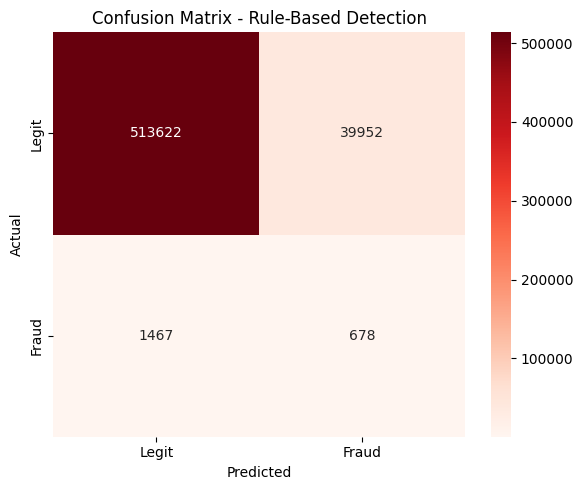

In [39]:
# Evaluate against actual labels if available
if 'is_fraud' in df.columns:
    from sklearn.metrics import classification_report, confusion_matrix

    print('=== Classification Report ===')
    print(classification_report(df['is_fraud'], df['predicted_fraud'], target_names=['Legit', 'Fraud']))

    cm = confusion_matrix(df['is_fraud'], df['predicted_fraud'])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix - Rule-Based Detection')
    plt.tight_layout(); plt.show()
else:
    print('No ground-truth labels found. Showing flag distribution only.')

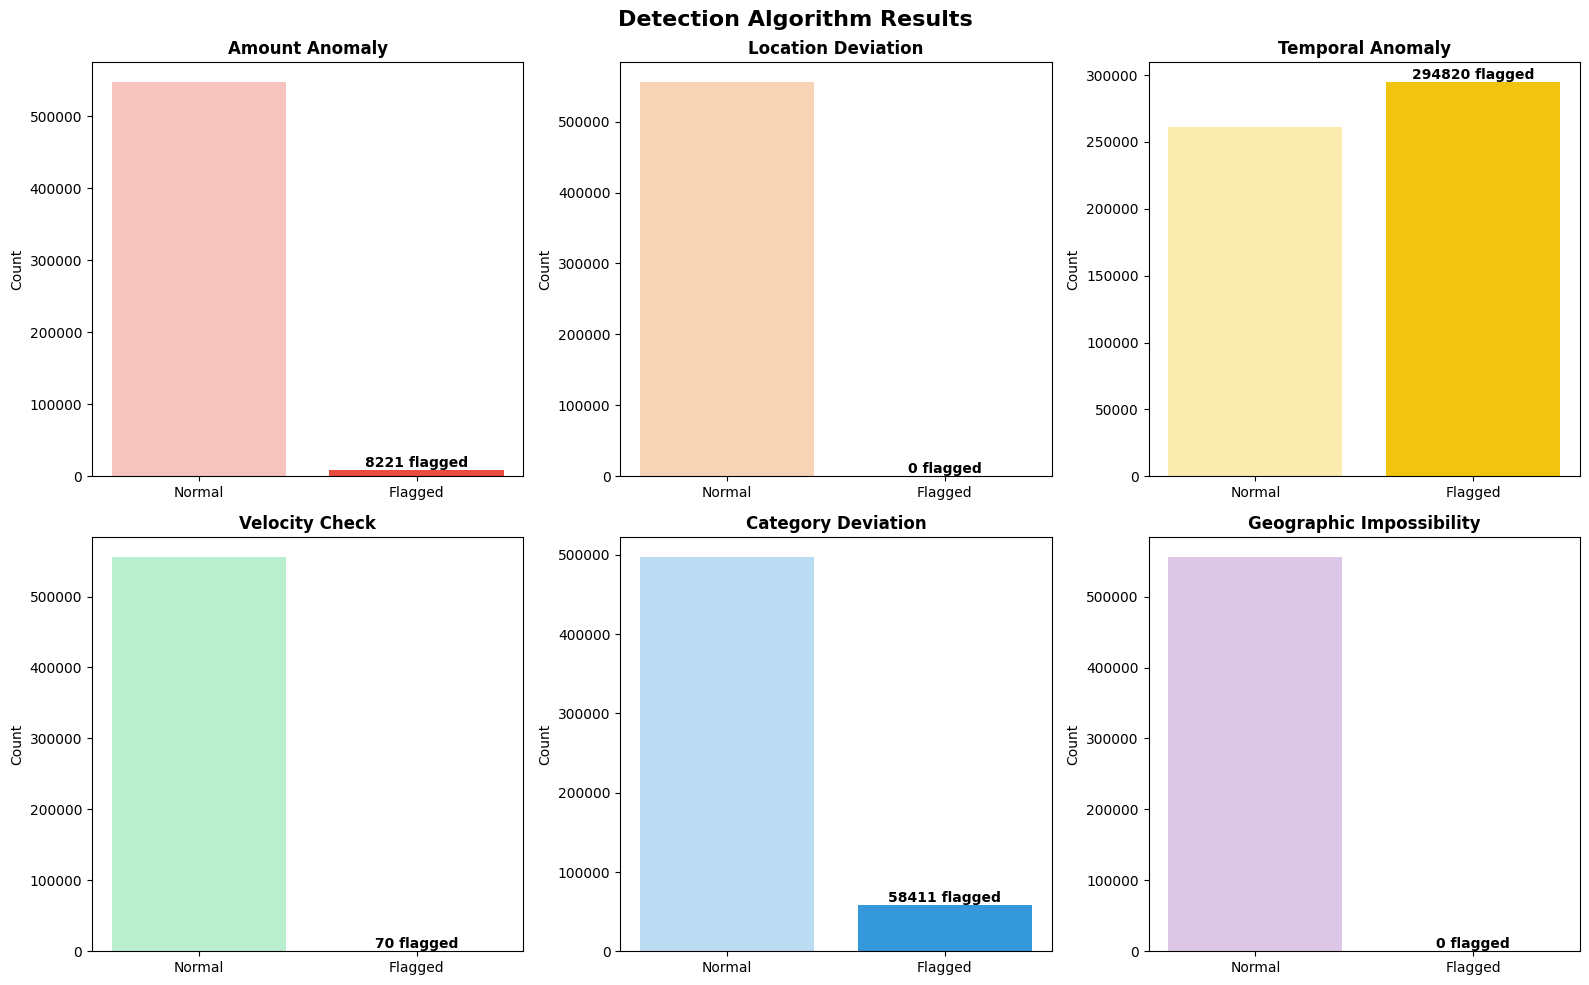

In [40]:
# Visualize which algorithms contributed most
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Detection Algorithm Results', fontsize=16, fontweight='bold')

alg_names = ['Amount Anomaly', 'Location Deviation', 'Temporal Anomaly',
             'Velocity Check', 'Category Deviation', 'Geographic Impossibility']
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']

for i, (flag, name, color) in enumerate(zip(existing_flags, alg_names, colors)):
    ax = axes[i // 3][i % 3]
    counts = df[flag].value_counts().sort_index()
    ax.bar(['Normal', 'Flagged'], [counts.get(0, 0), counts.get(1, 0)], color=[color + '55', color])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Count')
    flagged_n = counts.get(1, 0)
    ax.annotate(f'{flagged_n} flagged', xy=(1, flagged_n), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [41]:
# Show some example flagged transactions
flagged_transactions = df[df['predicted_fraud'] == 1].sort_values('fraud_score', ascending=False)
display_cols = ['user_id', 'timestamp', 'amount', 'category', 'fraud_score'] + existing_flags
display_cols = [c for c in display_cols if c in flagged_transactions.columns]
print(f'\n🚨 Top 10 Most Suspicious Transactions:')
flagged_transactions[display_cols].head(10)


🚨 Top 10 Most Suspicious Transactions:


,user_id,timestamp,amount,category,fraud_score,flag_amount_anomaly,flag_location_deviation,flag_temporal_anomaly,flag_velocity,flag_category_deviation,flag_geo_impossible
553931,4973530368125489546,2020-09-06 14:42:19,1060.58,travel,3,1,0,1,0,1,0
553450,4958589671582726883,2020-10-18 23:49:12,751.72,misc_net,3,1,0,1,0,1,0
553449,4958589671582726883,2020-10-18 22:06:22,773.33,misc_net,3,1,0,1,0,1,0
552581,4956828990005111019,2020-10-22 04:03:06,560.43,misc_net,3,1,0,1,0,1,0
552066,4956828990005111019,2020-07-12 02:39:17,571.75,misc_net,3,1,0,1,0,1,0
552015,4956828990005111019,2020-07-02 03:23:51,730.98,misc_net,3,1,0,1,0,1,0
550500,4897067971111209737,2020-07-13 04:19:23,476.86,misc_net,3,1,0,1,0,1,0
548354,4855488158131690372,2020-12-24 15:52:20,567.71,travel,3,1,0,1,0,1,0
548271,4855488158131690372,2020-12-14 15:43:50,499.26,travel,3,1,0,1,0,1,0
548223,4855488158131690372,2020-12-08 21:10:37,525.34,travel,3,1,0,1,0,1,0


---
## Summary

| # | Algorithm | What It Detects | Key Metric |
|---|-----------|-----------------|------------|
| 1 | Amount Anomaly | Unusual transaction amounts | Z-score > 3σ |
| 2 | Location Deviation | Transactions far from home | Distance > 5000km |
| 3 | Temporal Analysis | Odd transaction hours | Hour usage < 5% |
| 4 | Velocity Check | Rapid-fire transactions | > 5 txns in 60 min |
| 5 | Category Deviation | Unusual merchant types | Category usage < 5% |
| 6 | Geographic Impossibility | Impossible travel speed | Speed > 900 km/h |

In [42]:
print('\n=== Individual Algorithm Performance ===')
from sklearn.metrics import accuracy_score, classification_report
if 'is_fraud' in df.columns:
    for flag in existing_flags:
        acc = accuracy_score(df['is_fraud'], df[flag])
        print(f'\n--- Performance of {flag} ---')
        print(f'Accuracy: {acc*100:.2f}%')
        print(classification_report(df['is_fraud'], df[flag], target_names=['Legit', 'Fraud'], zero_division=0))
else:
    print('No ground truth labels to evaluate individual accuracy.')



=== Individual Algorithm Performance ===

--- Performance of flag_amount_anomaly ---
Accuracy: 98.45%
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99    553574
       Fraud       0.11      0.41      0.17      2145

    accuracy                           0.98    555719
   macro avg       0.55      0.70      0.58    555719
weighted avg       0.99      0.98      0.99    555719


--- Performance of flag_location_deviation ---
Accuracy: 99.61%
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    553574
       Fraud       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719


--- Performance of flag_temporal_anomaly ---
Accuracy: 46.98%
              precision    recall  f1-score   support

       Legit       1.00      0.47      0.64    553574
      